In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
import warnings as wr
wr.filterwarnings("ignore")
# -------------------------------- #
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
    StackingClassifier,
    VotingClassifier
)
from xgboost import XGBClassifier
# -------------------------------- #
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)
# -------------------------------- #
from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV
)
# -------------------------------- #
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)
# -------------------------------- #
# Pickle Model in Production # 
import joblib as jb

In [4]:
df=pd.read_csv("water_potability-updated.csv")

In [5]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.080795,219.674262,22210.613083,5.875041,333.775777,398.517703,11.502316,112.412210,2.994259,0
1,6.783888,193.653581,13677.106441,5.171454,323.728663,477.854687,15.056064,66.396293,3.250022,0
2,6.010618,184.558582,15940.573271,8.165222,421.486089,314.529813,20.314617,83.707938,4.867287,1
3,8.097454,218.992436,18112.284447,6.196947,333.775777,376.569803,17.746264,59.909941,4.279082,1
4,8.072612,210.269780,16843.363927,8.793459,359.516169,559.167574,17.263576,68.738989,5.082206,0


In [6]:
df.columns

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='str')

In [7]:
print("The Number of Rows :",df.shape[0],"\nThe Number of Columns :",df.shape[1])

The Number of Rows : 9154 
The Number of Columns : 10


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9154 entries, 0 to 9153
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               9154 non-null   float64
 1   Hardness         9154 non-null   float64
 2   Solids           9154 non-null   float64
 3   Chloramines      9154 non-null   float64
 4   Sulfate          9154 non-null   float64
 5   Conductivity     9154 non-null   float64
 6   Organic_carbon   9154 non-null   float64
 7   Trihalomethanes  9154 non-null   float64
 8   Turbidity        9154 non-null   float64
 9   Potability       9154 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 715.3 KB


In [9]:
df.isnull().sum().sort_values(ascending=False)

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

In [10]:
print(f"Number of Duplicated Recordes : {df.duplicated().sum()}")

Number of Duplicated Recordes : 519


In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.reset_index(drop=True,inplace=True)

In [13]:
print('Unique : ', df.Potability.unique())
print('------------------------------')

print('Number Of Unique : ', df.Potability.nunique())
print('------------------------------')

print('Value_Counts : ')
print(df.Potability.value_counts())
print('------------------------------')

Unique :  [0 1]
------------------------------
Number Of Unique :  2
------------------------------
Value_Counts : 
Potability
0    5263
1    3372
Name: count, dtype: int64
------------------------------


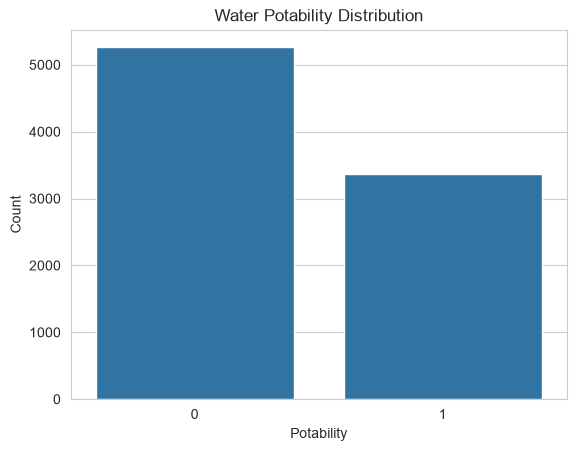

In [14]:
sns.countplot(data=df, x='Potability')
plt.title('Water Potability Distribution')
plt.xlabel('Potability')
plt.ylabel('Count')
plt.show()

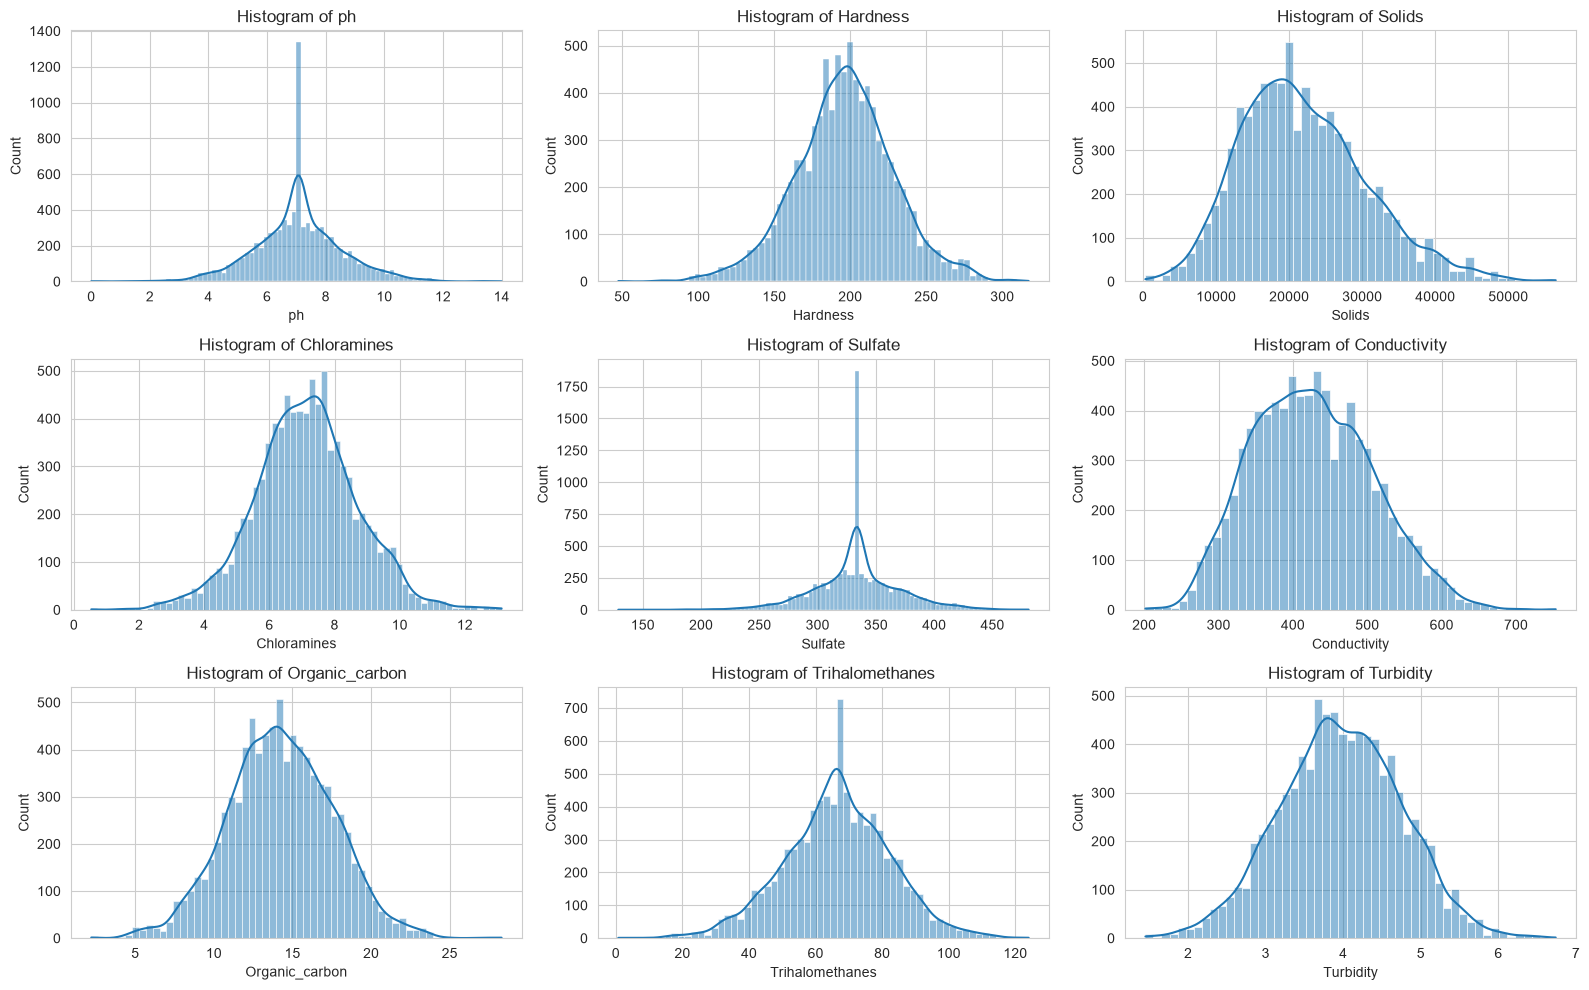

In [15]:
row, cols = 3, 3

fig, axes = plt.subplots(
    row,
    cols,
    figsize=(16, 10)
)

axes = axes.flatten()

data_num = df.drop("Potability", axis=1)

for i, col in enumerate(data_num.columns):

    sns.histplot(
        data_num[col],
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(f"Histogram of {col}")

plt.tight_layout()
plt.show()

In [16]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,8635.000000,8635.000000,8635.000000,8635.000000,8635.000000,8635.000000,8635.000000,8635.000000,8635.000000,8635.000000
mean,7.081845,196.381861,21992.011715,7.124134,333.748907,426.071630,14.267143,66.430776,3.969276,0.390504
std,1.497877,32.543367,8649.016941,1.576449,37.280138,80.530919,3.322199,15.883218,0.778976,0.487892
min,0.000000,47.432000,320.942611,0.530351,129.000000,201.619737,2.200000,0.738000,1.450000,0.000000
25%,6.246191,176.808661,15755.094886,6.132546,314.897040,365.272966,12.049131,56.435647,3.440859,0.000000
50%,7.080795,197.142637,20988.087806,7.120773,333.775777,421.664483,14.189857,66.396293,3.961942,0.000000
75%,7.894071,216.421982,27317.099444,8.095991,352.306586,481.955877,16.542239,77.079780,4.510578,1.000000
max,14.000000,317.338124,56488.672413,13.127000,481.030643,753.342620,28.300000,124.000000,6.739000,1.000000


In [17]:
df.drop('Potability' , axis = 1).corr()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
ph,1.000000,0.092381,-0.080842,-0.025905,0.016900,0.021562,0.033533,0.005740,-0.043640
Hardness,0.092381,1.000000,-0.045643,-0.030564,-0.089479,-0.021658,0.002675,-0.016761,-0.011484
Solids,-0.080842,-0.045643,1.000000,-0.060072,-0.151353,0.010972,0.012000,-0.002604,0.028516
Chloramines,-0.025905,-0.030564,-0.060072,1.000000,0.027590,-0.013791,-0.017801,0.019178,0.005797
Sulfate,0.016900,-0.089479,-0.151353,0.027590,1.000000,-0.016116,0.024998,-0.027522,-0.014302
Conductivity,0.021562,-0.021658,0.010972,-0.013791,-0.016116,1.000000,0.016701,-0.003476,0.006470
Organic_carbon,0.033533,0.002675,0.012000,-0.017801,0.024998,0.016701,1.000000,-0.018136,-0.019453
Trihalomethanes,0.005740,-0.016761,-0.002604,0.019178,-0.027522,-0.003476,-0.018136,1.000000,-0.019468
Turbidity,-0.043640,-0.011484,0.028516,0.005797,-0.014302,0.006470,-0.019453,-0.019468,1.000000


In [18]:
df.sample(5)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
8381,8.458797,241.768340,29317.142440,5.783276,313.885548,328.579429,18.296001,84.510986,3.827432,1
956,8.151249,205.847301,15661.940335,7.009437,335.622779,555.590284,14.861133,72.762585,2.799883,1
1353,7.678945,178.200542,20243.088195,7.099474,333.775777,363.974060,11.913204,58.273700,3.089550,1
6572,7.256015,196.649823,44184.230460,5.265558,260.425605,324.250148,8.148929,69.375044,4.534960,1
5606,9.166758,184.557434,21736.981799,12.227175,304.528521,317.583367,16.779566,51.052288,5.429267,1


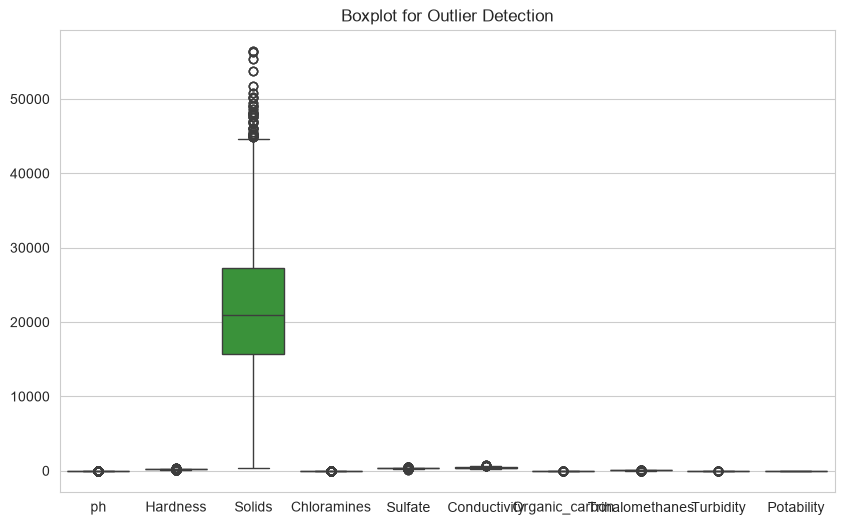

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.title('Boxplot for Outlier Detection')
plt.show()

In [20]:
for col in df.columns:
    print(
        f"{col:20} | Min: {df[col].min():.2f} | Max: {df[col].max():.2f}"
    )

ph                   | Min: 0.00 | Max: 14.00
Hardness             | Min: 47.43 | Max: 317.34
Solids               | Min: 320.94 | Max: 56488.67
Chloramines          | Min: 0.53 | Max: 13.13
Sulfate              | Min: 129.00 | Max: 481.03
Conductivity         | Min: 201.62 | Max: 753.34
Organic_carbon       | Min: 2.20 | Max: 28.30
Trihalomethanes      | Min: 0.74 | Max: 124.00
Turbidity            | Min: 1.45 | Max: 6.74
Potability           | Min: 0.00 | Max: 1.00


In [21]:
Q1 = df["Solids"].quantile(0.25)
Q3 = df["Solids"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    (df[col] >= lower) &
    (df[col] <= upper)
]

In [22]:
df.drop('Potability' , axis = 1).corr()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
ph,1.000000,0.092381,-0.080842,-0.025905,0.016900,0.021562,0.033533,0.005740,-0.043640
Hardness,0.092381,1.000000,-0.045643,-0.030564,-0.089479,-0.021658,0.002675,-0.016761,-0.011484
Solids,-0.080842,-0.045643,1.000000,-0.060072,-0.151353,0.010972,0.012000,-0.002604,0.028516
Chloramines,-0.025905,-0.030564,-0.060072,1.000000,0.027590,-0.013791,-0.017801,0.019178,0.005797
Sulfate,0.016900,-0.089479,-0.151353,0.027590,1.000000,-0.016116,0.024998,-0.027522,-0.014302
Conductivity,0.021562,-0.021658,0.010972,-0.013791,-0.016116,1.000000,0.016701,-0.003476,0.006470
Organic_carbon,0.033533,0.002675,0.012000,-0.017801,0.024998,0.016701,1.000000,-0.018136,-0.019453
Trihalomethanes,0.005740,-0.016761,-0.002604,0.019178,-0.027522,-0.003476,-0.018136,1.000000,-0.019468
Turbidity,-0.043640,-0.011484,0.028516,0.005797,-0.014302,0.006470,-0.019453,-0.019468,1.000000


In [23]:
Inputs = df.drop("Potability", axis=1)
Target=df["Potability"]

In [24]:
xTrain,xTest,yTrain,yTest=train_test_split(Inputs,Target,test_size=0.2,stratify=Target,shuffle=True,random_state=42)

In [25]:
Numerical_Feature = [
    "ph",
    "Hardness",
    "Solids",
    "Chloramines",
    "Sulfate",
    "Conductivity",
    "Organic_carbon",
    "Trihalomethanes",
    "Turbidity"
]

In [26]:
Numeric_Transformer=Pipeline(steps=[
        ("Scaler",StandardScaler())
    ],
)

In [27]:
PreProcessor=ColumnTransformer(transformers=[
        ("Num",Numeric_Transformer,Numerical_Feature)
])

In [28]:
Models = {

    # Linear Model
    "LogisticRegression": LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight="balanced"
    ),
    # Distance / Kernel
    "KNN": KNeighborsClassifier(),
    # Tree
    "DecisionTree": DecisionTreeClassifier(
        random_state=42,                
        class_weight="balanced"
    ),
    # Ensemble
    "RandomForest": RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ),
    
    "GradientBoosting": GradientBoostingClassifier(
        random_state=42
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        random_state=42,
        class_weight="balanced"
    ),
    # XGBoost
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
}

In [29]:
Results = []
# -------------------------------------------- #
for Name, model in Models.items():
    Pipe = Pipeline(steps=[
        ("PreProcessor", PreProcessor),
        ("Model", model)
    ])
    Pipe.fit(xTrain, yTrain)
    # -------------------------------------------- #
    # Predictions
    yPredict_Train = Pipe.predict(xTrain)
    yPredict_Test = Pipe.predict(xTest)
    # -------------------------------------------- #
    # Probabilities
    if hasattr(Pipe, "predict_proba"):
        yPredict_Prob = Pipe.predict_proba(xTest)[:, 1]
    else:
        yPredict_Prob = Pipe.decision_function(xTest)
    # -------------------------------------------- #
    # Train Metrics
    Accuracy_Train = accuracy_score(yTrain, yPredict_Train)
    Precision_Train = precision_score(yTrain, yPredict_Train)
    Recall_Train = recall_score(yTrain, yPredict_Train)
    F1_Train = f1_score(yTrain, yPredict_Train)
    # -------------------------------------------- #
    # Test Metrics
    Accuracy_Test = accuracy_score(yTest, yPredict_Test)
    Precision_Test = precision_score(yTest, yPredict_Test)
    Recall_Test = recall_score(yTest, yPredict_Test)
    F1_Test = f1_score(yTest, yPredict_Test)
    ROC_AUC_Test = roc_auc_score(yTest, yPredict_Prob)
    # -------------------------------------------- #
    # Cross Validation
    # -------------------------------------------- #
    CV_F1 = cross_val_score(
        estimator=Pipe,
        X=Inputs,
        y=Target,
        cv=5,
        scoring="f1"
    ).mean()

    Results.append({
        "Model": Name,

        "Train Accuracy": Accuracy_Train,
        "Train Precision": Precision_Train,
        "Train Recall": Recall_Train,
        "Train F1": F1_Train,

        "Test Accuracy": Accuracy_Test,
        "Test Precision": Precision_Test,
        "Test Recall": Recall_Test,
        "Test F1": F1_Test,
        "Test ROC-AUC": ROC_AUC_Test,

        "CV F1": CV_F1,
    })

In [30]:
Results_df = pd.DataFrame(Results)

In [31]:
Results_df

,Model,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,CV F1
0,LogisticRegression,0.533874,0.420037,0.508154,0.459913,0.510712,0.395092,0.477745,0.432505,0.505828,0.447562
1,KNN,0.891865,0.880609,0.836546,0.858012,0.689056,0.613223,0.550445,0.580141,0.845741,0.627729
2,DecisionTree,1.000000,1.000000,1.000000,1.000000,0.984366,0.986466,0.973294,0.979836,0.982373,0.999852
3,RandomForest,1.000000,1.000000,1.000000,1.000000,0.984366,0.986466,0.973294,0.979836,0.997455,1.000000
4,GradientBoosting,0.752316,0.868009,0.431431,0.576380,0.712218,0.786408,0.360534,0.494405,0.775279,0.543018
5,HistGradientBoosting,0.969456,0.958011,0.964047,0.961020,0.906775,0.881129,0.879822,0.880475,0.962292,0.946309
6,XGBoost,0.997684,0.999627,0.994440,0.997027,0.969890,0.987461,0.934718,0.960366,0.986589,0.995832


In [32]:
PipeLineOne = Pipeline(steps=[
    ("PreProcessor", PreProcessor),
    ("DecisionTreeClassifier", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

# Training
PipeLineOne.fit(xTrain, yTrain)

# Predictions
yPredict_Train = PipeLineOne.predict(xTrain)
yPredict_Test = PipeLineOne.predict(xTest)

print("---------------------------")
print("RandomForestClassifier")

print(f"Accuracy For Train Data: {accuracy_score(yTrain, yPredict_Train):.4f}")
print(f"F1 For Train Data: {f1_score(yTrain, yPredict_Train):.4f}")

print(f"Accuracy For Test Data: {accuracy_score(yTest, yPredict_Test):.4f}")
print(f"F1 For Test Data: {f1_score(yTest, yPredict_Test):.4f}")

print("---------------------------")

---------------------------
RandomForestClassifier
Accuracy For Train Data: 1.0000
F1 For Train Data: 1.0000
Accuracy For Test Data: 0.9844
F1 For Test Data: 0.9798
---------------------------


In [33]:
print('Confusion Matrix for RandomForestClassifier : ')
print(confusion_matrix(yTest, yPredict_Test))
print('-------------------------------------------------')
print(accuracy_score(yTest, yPredict_Test))
print('-------------------------------------------------')
print(classification_report(yTest, yPredict_Test))

Confusion Matrix for RandomForestClassifier : 
[[1044    9]
 [  18  656]]
-------------------------------------------------
0.9843659525188188
-------------------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1053
           1       0.99      0.97      0.98       674

    accuracy                           0.98      1727
   macro avg       0.98      0.98      0.98      1727
weighted avg       0.98      0.98      0.98      1727



In [34]:
PipeLineTwo = Pipeline(steps=[
    ("PreProcessor", PreProcessor),
    ("RandomForest", RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

# Training
PipeLineTwo.fit(xTrain, yTrain)

# Predictions
yPredict_Train = PipeLineTwo.predict(xTrain)
yPredict_Test = PipeLineTwo.predict(xTest)

print("---------------------------")
print("RandomForestClassifier")

print(f"Accuracy For Train Data: {accuracy_score(yTrain, yPredict_Train):.4f}")
print(f"F1 For Train Data: {f1_score(yTrain, yPredict_Train):.4f}")

print(f"Accuracy For Test Data: {accuracy_score(yTest, yPredict_Test):.4f}")
print(f"F1 For Test Data: {f1_score(yTest, yPredict_Test):.4f}")

print("---------------------------")

---------------------------
RandomForestClassifier
Accuracy For Train Data: 1.0000
F1 For Train Data: 1.0000
Accuracy For Test Data: 0.9844
F1 For Test Data: 0.9798
---------------------------


In [35]:
print('Confusion Matrix for RandomForestClassifier : ')
print(confusion_matrix(yTest, yPredict_Test))
print('-------------------------------------------------')
print(accuracy_score(yTest, yPredict_Test))
print('-------------------------------------------------')
print(classification_report(yTest, yPredict_Test))

Confusion Matrix for RandomForestClassifier : 
[[1044    9]
 [  18  656]]
-------------------------------------------------
0.9843659525188188
-------------------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1053
           1       0.99      0.97      0.98       674

    accuracy                           0.98      1727
   macro avg       0.98      0.98      0.98      1727
weighted avg       0.98      0.98      0.98      1727



In [36]:
PipeLineThree = Pipeline(steps=[
    ("PreProcessor", PreProcessor),
    ("Model", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

PipeLineThree.fit(xTrain, yTrain)

# Predictions
yPredict_Train = PipeLineThree.predict(xTrain)
yPredict_Test = PipeLineThree.predict(xTest)

print("---------------------------")
print("XGBClassifier")

print(f"Accuracy For Train Data: {accuracy_score(yTrain, yPredict_Train):.4f}")
print(f"F1 For Train Data: {f1_score(yTrain, yPredict_Train):.4f}")

print(f"Accuracy For Test Data: {accuracy_score(yTest, yPredict_Test):.4f}")
print(f"F1 For Test Data: {f1_score(yTest, yPredict_Test):.4f}")

print("---------------------------")

---------------------------
XGBClassifier
Accuracy For Train Data: 0.9977
F1 For Train Data: 0.9970
Accuracy For Test Data: 0.9699
F1 For Test Data: 0.9604
---------------------------


In [37]:
print('Confusion Matrix for RandomForestClassifier : ')
print(confusion_matrix(yTest, yPredict_Test))
print('-------------------------------------------------')
print(accuracy_score(yTest, yPredict_Test))
print('-------------------------------------------------')
print(classification_report(yTest, yPredict_Test))

Confusion Matrix for RandomForestClassifier : 
[[1045    8]
 [  44  630]]
-------------------------------------------------
0.9698899826288361
-------------------------------------------------
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1053
           1       0.99      0.93      0.96       674

    accuracy                           0.97      1727
   macro avg       0.97      0.96      0.97      1727
weighted avg       0.97      0.97      0.97      1727



In [38]:
from sklearn.inspection import permutation_importance
# Calculate permutation importance
perm = permutation_importance(
    PipeLineTwo,
    xTest,
    yTest,
    scoring="f1",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Feature importance
feature_importance = pd.DataFrame({
    "Feature": xTest.columns,
    "Importance": perm.importances_mean
}).sort_values(
    "Importance",
    ascending=False
)

print(feature_importance)

           Feature  Importance
4          Sulfate    0.190871
0               ph    0.157930
1         Hardness    0.106688
3      Chloramines    0.088628
2           Solids    0.068330
5     Conductivity    0.022091
6   Organic_carbon    0.015322
7  Trihalomethanes    0.008460
8        Turbidity    0.003387


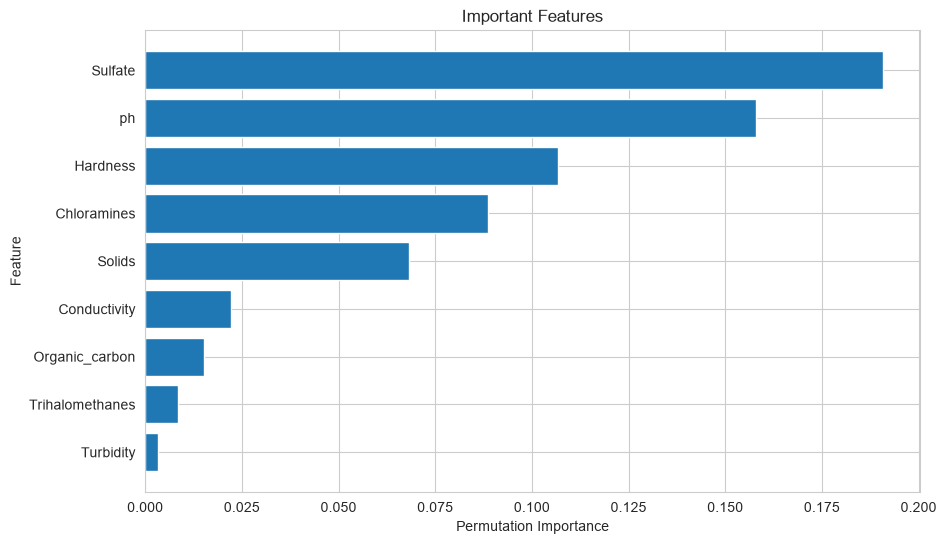

In [39]:
top_features = feature_importance

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Important Features")
plt.show()

In [40]:
# Pickle Model # 
jb.dump(PipeLineTwo,"PipeLineTwo.pkl")
print("The Model is Saved")

The Model is Saved


In [41]:
# InputsDataFrame = pd.DataFrame([{
#     "ph": 7.2,
#     "Hardness": 180.5,
#     "Solids": 12000.0,
#     "Chloramines": 7.0,
#     "Sulfate": 330.0,
#     "Conductivity": 420.0,
#     "Organic_carbon": 14.5,
#     "Trihalomethanes": 65.0,
#     "Turbidity": 4.0
# }])

In [42]:
LoadModel=jb.load("PipeLineTwo.pkl")
# # --------------------------------- #
InputsDataFrame = pd.DataFrame([{
    "ph": 7.2,
    "Hardness": 180.5,
    "Solids": 12000.0,
    "Chloramines": 7.0,
    "Sulfate": 330.0,
    "Conductivity": 420.0,
    "Organic_carbon": 14.5,
    "Trihalomethanes": 65.0,
    "Turbidity": 4.0
}])


In [43]:
# # --------------------------------- #
Prediction = LoadModel.predict(InputsDataFrame)[0]
# # --------------------------------- #
if Prediction == 1:
    print("Water is Potable ✅")
else:
    print("Water is Not Potable ❌")

Water is Not Potable ❌
